In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lgd_eval_utils import eval_glm, eval_itb, eval_gplm, eval_gpb

import sys
# sys.path.append("PATH TO loglikelihood_utils")

from QB_utils import sample_QB, QB_nll, QB_ll_given_loc, QB_predictive_mean
from ZOCN_utils import sample_ZOCN, ZOCN_nll, ZOCN_predictive_mean, ZOCN_predictive_distribution, ZOCN_randomized_pit
from BEINF_utils import sample_BEINF, BEINF_nll, BEINF_predictive_mean, BEINF_predictive_distribution, BEINF_randomized_pit
from ZOCTN_utils import sample_ZOCTN, ZOCTN_nll, ZOCTN_ll_given_mu, ZOCTN_predictive_mean, ZOCTN_predictive_distribution, ZOCTN_randomized_pit
from ZOCSG_utils import sample_ZOCSG, ZOCSG_nll, ZOCSG_ll_given_loc, ZOCSG_predictive_mean, ZOCSG_predictive_distribution, ZOCSG_nll_i, ZOCSG_randomized_pit
from ZOCTB_utils import sample_ZOCTB, ZOCTB_nll, ZOCTB_predictive_mean, ZOCTB_predictive_distribution, ZOCTB_randomized_pit

# sys.path.append("PATH TO eval_utils")
from eval_utils import plot_pit_residuals_two_panel

/Users/christopher/Documents/University/ETH MScQF/Term 3/Thesis/working_project/mscqf_thesis/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/christopher/Documents/University/ETH MScQF/Term 3/Thesis/working_project/mscqf_thesis/lib/python3.12/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
sfeature_cols = ["X_centroid", "Y_centroid", "credit_score", "occupancy", "nr_units", "loan_purpose", "first_time_homebuyer", "MSA", 
                "insurance_percent", "original_debt_to_income", "original_loan_to_value", "original_upb", "number_of_borrowers", "ir_spread", 
                "n_months", "ltv_at_default", "gdp_growth", "ln_income_per_capita", "ln_expenditures_per_capita", "unemployment_rate", 
                "hpi_growth", "gdp_construction_growth", "gross_operating_surplus_growth", "inflation_rate", "DJIA_growth"]
stfeature_cols = ["year_default", "X_centroid", "Y_centroid", "credit_score", "occupancy", "nr_units", "loan_purpose", "first_time_homebuyer", "MSA", 
                "insurance_percent", "original_debt_to_income", "original_loan_to_value", "original_upb", "number_of_borrowers", "ir_spread", 
                "n_months", "ltv_at_default", "gdp_growth", "ln_income_per_capita", "ln_expenditures_per_capita", "unemployment_rate", 
                "hpi_growth", "gdp_construction_growth", "gross_operating_surplus_growth", "inflation_rate", "DJIA_growth"]
target_col = ["LGD"]
scoords_cols = ["X_centroid", "Y_centroid"]
stcoords_cols = ["year_default", "X_centroid", "Y_centroid"]

categorical_cols = ["occupancy", "loan_purpose", "first_time_homebuyer", "MSA", "number_of_borrowers"]

year_range = [i for i in range(2008, 2023)]

N_is = [] 
N_os = [] 

TIME_VERSIONING_DATA_PATH = "data/processed_data/time_versioning/"

for year in year_range:
    train_df = pd.read_feather(TIME_VERSIONING_DATA_PATH+f"{year}_snapshot/training_data.feather")
    test_df = pd.read_feather(TIME_VERSIONING_DATA_PATH+f"{year}_snapshot/testing_data.feather")
    N_is.append(len(train_df))
    N_os.append(len(test_df))

w_is, w_os = N_is / np.sum(N_is), N_os / np.sum(N_os)

# In-sample (Goodness-of-Fit) Model Evaluation

In [3]:
nll_dict = {
    "QB": {"obj": QB_nll, 'sample_func': sample_QB, 'pred_mu': QB_predictive_mean, 'N_aux_params': 0},
    "ZOCN": {"obj": ZOCN_nll, 'sample_func': sample_ZOCN, 'pred_mu': ZOCN_predictive_mean, 'N_aux_params': 1}, 
    'BEINF': {"obj": BEINF_nll, 'sample_func': sample_BEINF, 'pred_mu': BEINF_predictive_mean, 'N_aux_params': 3}, 
    "ZOCSG": {"obj": ZOCSG_nll, 'sample_func': sample_ZOCSG, 'pred_mu': ZOCSG_predictive_mean, 'N_aux_params': 2, 'nll_i': ZOCSG_nll_i}, 
    "ZOCTB": {"obj": ZOCTB_nll, 'sample_func': sample_ZOCTB, 'pred_mu': ZOCTB_predictive_mean, 'N_aux_params': 2},
    "ZOCTN": {"obj": ZOCTN_nll, 'sample_func': sample_ZOCTN, 'pred_mu': ZOCTN_predictive_mean, 'N_aux_params': 3}, 
}

yearly_eval_data = {}
for y in year_range:
    eval_dict = eval_glm(nll_dict, y, sfeature_cols, target_col)
    yearly_eval_data[y] = eval_dict

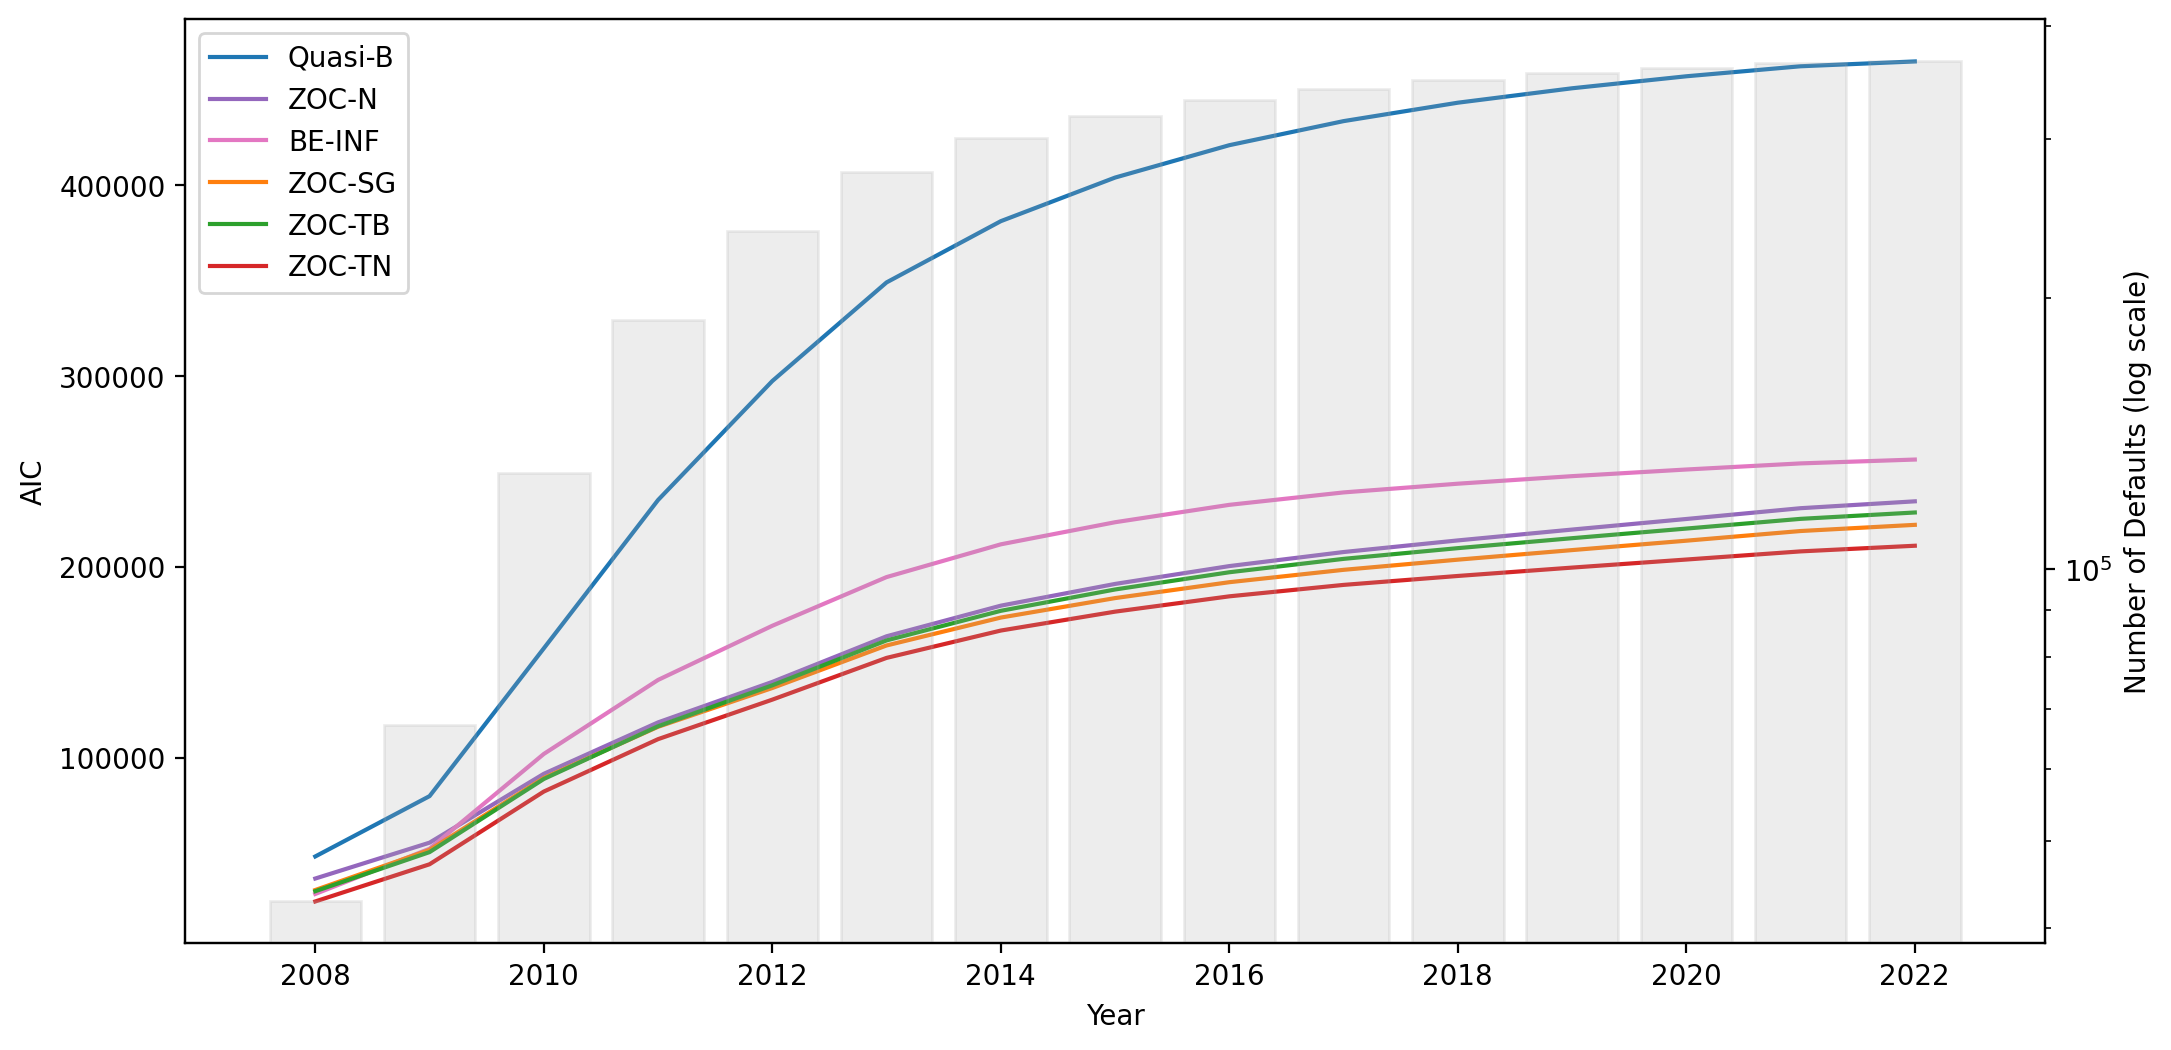

In [4]:
from lgd_eval_utils import plot_is_ilm_aic

plot_is_ilm_aic(yearly_eval_data, year_range, N_is)

In [5]:
from lgd_eval_utils import ilm_is_performance

is_df = ilm_is_performance(yearly_eval_data, year_range)
is_df

,NLL (Final),AIC (Final),BIC (Final)
Bernoulli,232476.63908227283,465009.27816454566,465311.92793355766
ZOC-Normal,117163.8963332957,234385.7926665914,234699.25135592528
BEINF,128113.64439798902,256289.28879597803,256624.36532595562
ZOCS-Gamma,110997.67267593925,222055.3453518785,222379.61296153424
ZOCT-Beta,114237.61253319882,228535.22506639763,228859.49267605337
ZOCT-Normal,105519.12302750708,211100.24605501417,211435.32258499175


## Model coefficients

In [6]:
from lgd_eval_utils import ilm_coeffs, display_coeffs

ilm_coeffs_dict = ilm_coeffs(nll_dict, sfeature_cols, target_col, categorical_cols)

qb_mle_df, zocn_mle_df, beinf_mle_df, zoctn_mle_df, zoctb_mle_df, zocsg_mle_df = display_coeffs(ilm_coeffs_dict)

In [7]:
qb_mle_df

,Parameter,Std (Hessian)
intercept,-0.078147,0.003507
X_centroid,0.251739,0.004020
Y_centroid,0.101704,0.003858
credit_score,-0.080572,0.003679
nr_units,0.076680,0.003973
insurance_percent,-0.326144,0.004574
original_debt_to_income,-0.010787,0.003613
original_loan_to_value,0.050118,0.007085
original_upb,-0.362866,0.004526
ir_spread,0.133732,0.004394


# One-year-ahead Prediction Evaluation

## Independent Linear Models

In [8]:
ilm_dict = {
    "ZOCTN": {"obj": ZOCTN_nll, 'sample_func': sample_ZOCTN, 'pred_mu': ZOCTN_predictive_mean, 'N_aux_params': 3, 'pit_func': ZOCTN_randomized_pit},
    "ZOCSG": {"obj": ZOCSG_nll, 'sample_func': sample_ZOCSG, 'pred_mu': ZOCSG_predictive_mean, 'N_aux_params': 2, 'pit_func': ZOCSG_randomized_pit},
    "ZOCTB": {"obj": ZOCTB_nll, 'sample_func': sample_ZOCTB, 'pred_mu': ZOCTB_predictive_mean, 'N_aux_params': 2, 'pit_func': ZOCTB_randomized_pit},
    "QB": {"obj": QB_nll, 'sample_func': sample_QB, 'pred_mu': QB_predictive_mean, 'N_aux_params': 0, 'pit_func': None},
    "ZOCN": {"obj": ZOCN_nll, 'sample_func': sample_ZOCN, 'pred_mu': ZOCN_predictive_mean, 'N_aux_params': 1, 'pit_func': ZOCN_randomized_pit},
    "BEINF": {"obj": BEINF_nll, 'sample_func': sample_BEINF, 'pred_mu': BEINF_predictive_mean, 'N_aux_params': 3, 'pit_func': BEINF_randomized_pit}
}

# metrics = ['Shortfall', 'q99', "MSE", "LS", "CRPS"]
metrics = ["MSE", "LS", "CRPS", "PIT_u"]

ilm_results = {
    model: {metric: [] for metric in metrics}
    for model in ilm_dict
}

for y in year_range:
    
    eval_dict = eval_glm(ilm_dict, y, sfeature_cols, target_col, stage_2=True)

    for model in ilm_dict:
        for metric in metrics:
            ilm_results[model][metric].append(eval_dict[model][metric])

In [9]:
model_rows = {}
pit_by_model = {}
N_os = np.array(N_os)

for model in ilm_results:

    avg_mse = np.sum(N_os * ilm_results[model]["MSE"]) / np.sum(N_os)
    std_mse = np.sqrt(np.sum(N_os * (ilm_results[model]["MSE"] - avg_mse)**2) / np.sum(N_os))

    avg_ls = np.sum(N_os * ilm_results[model]["LS"]) / np.sum(N_os)
    std_ls = np.sqrt(np.sum(N_os * (ilm_results[model]["LS"] - avg_ls)**2) / np.sum(N_os))

    avg_crps = np.sum(N_os * ilm_results[model]["CRPS"]) / np.sum(N_os)
    std_crps = np.sqrt(np.sum(N_os * (ilm_results[model]["CRPS"] - avg_crps)**2) / np.sum(N_os))

    # Include economic metrics if calculated
    # mae_shortfall = np.mean(np.abs(ilm_results[model]["OS_Shortfall"]))

    # q99loss = np.sum(ilm_results[model]["OS_q99"])

    model_rows[f"GLM {model}"] = {
        "MSE": avg_mse,
        "MSE Std.": std_mse,
        "Log Score": avg_ls,
        "LS Std.": std_ls,
        "CRPS": avg_crps,
        "CRPS Std.": std_crps,
        # "MAE Shortfall": mae_shortfall,
        # "Q99": q99loss,
    }
    
    if model != 'QB':
        pit_by_model[f"LM: {model}"] = np.concatenate(ilm_results[model]['PIT_u'])

glm_df = pd.DataFrame.from_dict(model_rows, orient="index").round(4)
glm_df

,MSE,MSE Std.,Log Score,LS Std.,CRPS,CRPS Std.
GLM ZOCTN,0.0846,0.0190,0.4297,0.1961,0.1710,0.0248
GLM ZOCSG,0.0826,0.0180,0.4204,0.1792,0.1681,0.0230
GLM ZOCTB,0.0832,0.0193,0.4326,0.1781,0.1693,0.0249
GLM QB,0.0847,0.0206,0.6916,0.0596,0.2447,0.0184
GLM ZOCN,0.0829,0.0193,0.4410,0.1917,0.1681,0.0243
GLM BEINF,0.0800,0.0123,0.4636,0.1744,0.3106,0.0652


## Independent Tree-boosting

In [10]:
itb_dict = {
    "zoctn": {
        "ll_given_loc": ZOCTN_ll_given_mu,
        "sample_func": sample_ZOCTN,
        "pit_func": ZOCTN_randomized_pit
    },
    "zero_one_censored_shifted_gamma": {
        "ll_given_loc": ZOCSG_ll_given_loc,
        "sample_func": sample_ZOCSG,
        "pit_func": ZOCSG_randomized_pit
    },
    "binomial_logit": {
        "ll_given_loc": QB_ll_given_loc,
        "sample_func": sample_QB,
        "pit_func": None
    },
}

# metrics = ["MSE", "LS", "CRPS", 'Shortfall', 'q99']
metrics = ["MSE", "LS", "CRPS", "PIT_u"]

itb_results = {
    model: {metric: [] for metric in metrics}
    for model in itb_dict
}

for y in year_range:
    eval_dict = eval_itb(itb_dict, y, sfeature_cols, target_col)

    for model in itb_dict:
        for metric in metrics:
            itb_results[model][metric].append(eval_dict[model][metric])

Finished loading model, total used 2 iterations
Finished loading model, total used 11 iterations
Finished loading model, total used 6 iterations
Finished loading model, total used 2 iterations
Finished loading model, total used 11 iterations
Finished loading model, total used 6 iterations
Finished loading model, total used 69 iterations
Finished loading model, total used 206 iterations
Finished loading model, total used 49 iterations
Finished loading model, total used 17 iterations
Finished loading model, total used 36 iterations
Finished loading model, total used 23 iterations
Finished loading model, total used 91 iterations
Finished loading model, total used 226 iterations
Finished loading model, total used 800 iterations
Finished loading model, total used 708 iterations
Finished loading model, total used 519 iterations
Finished loading model, total used 800 iterations
Finished loading model, total used 800 iterations
Finished loading model, total used 230 iterations
Finished loading

In [11]:
model_rows = {}
N_os = np.array(N_os)

for model in itb_results:

    avg_mse = np.sum(N_os * itb_results[model]["MSE"]) / np.sum(N_os)
    std_mse = np.sqrt(np.sum(N_os * (itb_results[model]["MSE"] - avg_mse)**2) / np.sum(N_os))

    avg_ls = np.sum(N_os * itb_results[model]["LS"]) / np.sum(N_os)
    std_ls = np.sqrt(np.sum(N_os * (itb_results[model]["LS"] - avg_ls)**2) / np.sum(N_os))

    avg_crps = np.sum(N_os * itb_results[model]["CRPS"]) / np.sum(N_os)
    std_crps = np.sqrt(np.sum(N_os * (itb_results[model]["CRPS"] - avg_crps)**2) / np.sum(N_os))

    # Include economic metrics if calculated
    # mae_shortfall = np.mean(np.abs(itb_results[model]["OS_Shortfall"]))

    # q99loss = np.sum(itb_results[model]["OS_q99"])

    model_rows[f"ITB {model}"] = {
        "MSE": avg_mse,
        "MSE Std.": std_mse,
        "Log Score": avg_ls,
        "LS Std.": std_ls,
        "CRPS": avg_crps,
        "CRPS Std.": std_crps,
        # "MAE Shortfall": mae_shortfall,
        # "Q99": q99loss,
    }

    if model != 'binomial_logit':
        pit_by_model[f"TB: {model}"] = np.concatenate(itb_results[model]['PIT_u'])

itb_df = pd.DataFrame.from_dict(model_rows, orient="index").round(4)
itb_df

,MSE,MSE Std.,Log Score,LS Std.,CRPS,CRPS Std.
ITB zoctn,0.0663,0.0127,-0.1315,0.1296,0.1460,0.0161
ITB zero_one_censored_shifted_gamma,0.0669,0.0106,0.3253,0.1493,0.1491,0.0149
ITB binomial_logit,0.0657,0.0123,0.6379,0.0305,0.2257,0.0136


## GPLMs

In [12]:
gplm_dict = {
    'spatial': {'feature_cols': sfeature_cols, 'coord_cols': scoords_cols}, 
    'spatio-temporal': {'feature_cols': stfeature_cols, 'coord_cols': stcoords_cols}, # excluded for time constraints
}

# metrics = ["MSE", "LS", "CRPS", 'Shortfall', 'q99']
metrics = ["MSE", "LS", "CRPS", "PIT_u"]

gplm_results = {
    model: {metric: [] for metric in metrics}
    for model in gplm_dict
}

for y in year_range:
    for model in gplm_dict:
        eval_dict = eval_gplm(model, 'zoctn', y, gplm_dict[model]['feature_cols'], target_col, gplm_dict[model]['coord_cols'], ZOCTN_ll_given_mu, sample_ZOCTN, ZOCTN_randomized_pit)

        for metric in metrics:
            gplm_results[model][metric].append(eval_dict[metric])

In [13]:
model_rows = {}
N_os = np.array(N_os)

for model in gplm_results:

    avg_mse = np.sum(N_os * gplm_results[model]["MSE"]) / np.sum(N_os)
    std_mse = np.sqrt(np.sum(N_os * (gplm_results[model]["MSE"] - avg_mse)**2) / np.sum(N_os))

    avg_ls = np.sum(N_os * gplm_results[model]["LS"]) / np.sum(N_os)
    std_ls = np.sqrt(np.sum(N_os * (gplm_results[model]["LS"] - avg_ls)**2) / np.sum(N_os))

    avg_crps = np.sum(N_os * gplm_results[model]["CRPS"]) / np.sum(N_os)
    std_crps = np.sqrt(np.sum(N_os * (gplm_results[model]["CRPS"] - avg_crps)**2) / np.sum(N_os))

    # Include economic metrics if calculated
    # mae_shortfall = np.mean(np.abs(gplm_results[model]["OS_Shortfall"]))

    # q99loss = np.sum(gplm_results[model]["OS_q99"])

    model_rows[f"GPLM {model}"] = {
        "MSE": avg_mse,
        "MSE Std.": std_mse,
        "Log Score": avg_ls,
        "LS Std.": std_ls,
        "CRPS": avg_crps,
        "CRPS Std.": std_crps,
        # "MAE Shortfall": mae_shortfall,
        # "Q99": q99loss,
    }

    pit_by_model[f"GPLM: {model}"] = np.concatenate(gplm_results[model]['PIT_u'])

gplm_df = pd.DataFrame.from_dict(model_rows, orient="index").round(4)
gplm_df

,MSE,MSE Std.,Log Score,LS Std.,CRPS,CRPS Std.
GPLM spatial,0.0721,0.0156,-0.0816,0.1179,0.1543,0.0168
GPLM spatio-temporal,0.0689,0.0201,-0.0980,0.2122,0.1512,0.0278


## GPBs

In [14]:
gpb_dict = {
    'spatial': {'feature_cols': sfeature_cols, 'coord_cols': scoords_cols}, 
    'spatio-temporal': {'feature_cols': stfeature_cols, 'coord_cols': stcoords_cols}, # excluded for time constraints
}

# metrics = ["MSE", "LS", "CRPS", 'Shortfall', 'q99']
metrics = ["MSE", "LS", "CRPS", "PIT_u"]

gpb_results = {
    model: {metric: [] for metric in metrics}
    for model in gpb_dict
}

for y in year_range:
    for model in gpb_dict:
        eval_dict = eval_gpb(model, 'zoctn', y, gpb_dict[model]['feature_cols'], target_col, gpb_dict[model]['coord_cols'], ZOCTN_ll_given_mu, sample_ZOCTN, ZOCTN_randomized_pit)

        for metric in metrics:
            gpb_results[model][metric].append(eval_dict[metric])

Finished loading model, total used 61 iterations
Finished loading model, total used 30 iterations
Finished loading model, total used 84 iterations
Finished loading model, total used 12 iterations
Finished loading model, total used 25 iterations
Finished loading model, total used 41 iterations
Finished loading model, total used 2 iterations
Finished loading model, total used 6 iterations
Finished loading model, total used 221 iterations
Finished loading model, total used 111 iterations
Finished loading model, total used 380 iterations
Finished loading model, total used 336 iterations
Finished loading model, total used 590 iterations
Finished loading model, total used 131 iterations
Finished loading model, total used 331 iterations
Finished loading model, total used 797 iterations
Finished loading model, total used 155 iterations
Finished loading model, total used 111 iterations
Finished loading model, total used 795 iterations
Finished loading model, total used 785 iterations
Finished l

In [15]:
model_rows = {}
N_os = np.array(N_os)

for model in gpb_results:

    avg_mse = np.sum(N_os * gpb_results[model]["MSE"]) / np.sum(N_os)
    std_mse = np.sqrt(np.sum(N_os * (gpb_results[model]["MSE"] - avg_mse)**2) / np.sum(N_os))

    avg_ls = np.sum(N_os * gpb_results[model]["LS"]) / np.sum(N_os)
    std_ls = np.sqrt(np.sum(N_os * (gpb_results[model]["LS"] - avg_ls)**2) / np.sum(N_os))

    avg_crps = np.sum(N_os * gpb_results[model]["CRPS"]) / np.sum(N_os)
    std_crps = np.sqrt(np.sum(N_os * (gpb_results[model]["CRPS"] - avg_crps)**2) / np.sum(N_os))

    # Include economic metrics if calculated
    # mae_shortfall = np.mean(np.abs(gpb_results[model]["OS_Shortfall"]))

    # q99loss = np.sum(gpb_results[model]["OS_q99"])

    model_rows[f"GPB {model}"] = {
        "MSE": avg_mse,
        "MSE Std.": std_mse,
        "Log Score": avg_ls,
        "LS Std.": std_ls,
        "CRPS": avg_crps,
        "CRPS Std.": std_crps,
        # "MAE Shortfall": mae_shortfall,
        # "Q99": q99loss,
    }

    pit_by_model[f"GPB: {model}"] = np.concatenate(gpb_results[model]['PIT_u'])

gpb_df = pd.DataFrame.from_dict(model_rows, orient="index").round(4)
gpb_df

,MSE,MSE Std.,Log Score,LS Std.,CRPS,CRPS Std.
GPB spatial,0.0721,0.0197,-0.0907,0.1791,0.1529,0.0250
GPB spatio-temporal,0.0572,0.0059,-0.2096,0.0816,0.1338,0.0073


## PIT Diagrams

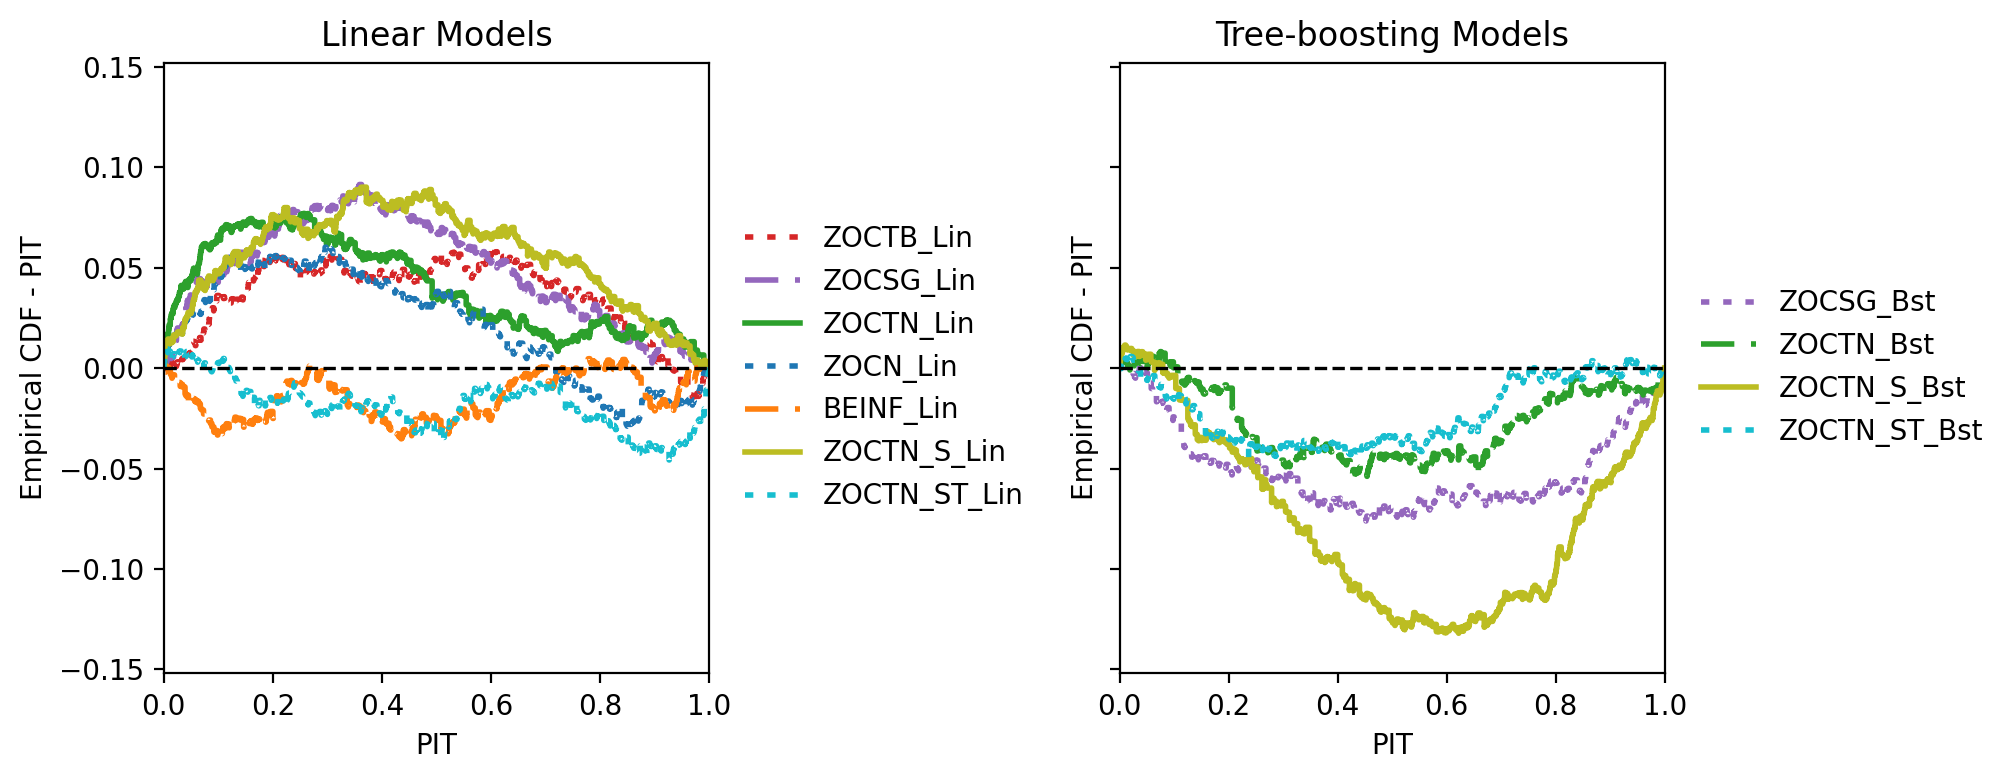

In [17]:
left_models = ['LM: ZOCTB', 'LM: ZOCSG', 'LM: ZOCTN', 'LM: ZOCN', 'LM: BEINF', 'GPLM: spatial', 'GPLM: spatio-temporal']
right_models = ['TB: zero_one_censored_shifted_gamma', 'TB: zoctn', 'GPB: spatial', 'GPB: spatio-temporal']

model_colors = {
    # 'LM: ZOC-N': 'tab:blue',
    # 'LM: BE-INF': 'tab:purple', 
    # 'LM: ZOC-TN': 'tab:green', 
    # 'LM: ZOC-TB': 'tab:red', 
    # 'LM: ZOC-SG': 'tab:orange', 
    'LM: ZOCTB': 'tab:red',
    'LM: ZOCSG': 'tab:purple',
    'LM: ZOCTN': 'tab:green',
    'LM: ZOCN':  'tab:blue',
    'LM: BEINF': 'tab:orange',
    # 'SGPLM': 'darkgreen', 
    # 'STGPLM': 'lawngreen',
    'GPLM: spatial': 'tab:olive', 
    'GPLM: spatio-temporal': 'tab:cyan',
    'TB: zoctn': 'tab:green', 
    'TB: zero_one_censored_shifted_gamma': 'tab:purple', 
    'GPB: spatial': 'tab:olive', 
    'GPB: spatio-temporal': 'tab:cyan'
}

model_ls = {
    'LM: ZOCTB': ':', 
    'LM: ZOCSG': '--', 
    'LM: ZOCTN': '-',
    'LM: ZOCN': ':',
    'LM: BEINF': '--',
    'GPLM: spatial': '-', 
    'GPLM: spatio-temporal': ':',

    'TB: zero_one_censored_shifted_gamma': ':',
    'TB: zoctn': '--', 
    'GPB: spatial': '-', 
    'GPB: spatio-temporal': ':'
}

display_names = {
    'LM: ZOCN': 'ZOCN_Lin',
    'LM: BEINF': 'BEINF_Lin', 
    'LM: ZOCTN': 'ZOCTN_Lin', 
    'LM: ZOCTB': 'ZOCTB_Lin', 
    'LM: ZOCSG': 'ZOCSG_Lin', 
    'GPLM: spatial': 'ZOCTN_S_Lin', 
    'GPLM: spatio-temporal': 'ZOCTN_ST_Lin',
    'TB: zoctn': 'ZOCTN_Bst', 
    'TB: zero_one_censored_shifted_gamma': 'ZOCSG_Bst', 
    'GPB: spatial': 'ZOCTN_S_Bst', 
    'GPB: spatio-temporal': 'ZOCTN_ST_Bst'
}

fig, axes = plot_pit_residuals_two_panel(
    pit_by_model=pit_by_model,
    left_models=left_models,
    right_models=right_models,
    model_colors=model_colors,
    model_ls=model_ls,
    display_names=display_names,
    titles=("Linear Models", "Tree-boosting Models"),
    figsize=(12, 4.0),
)

plt.show()

## Annual performance

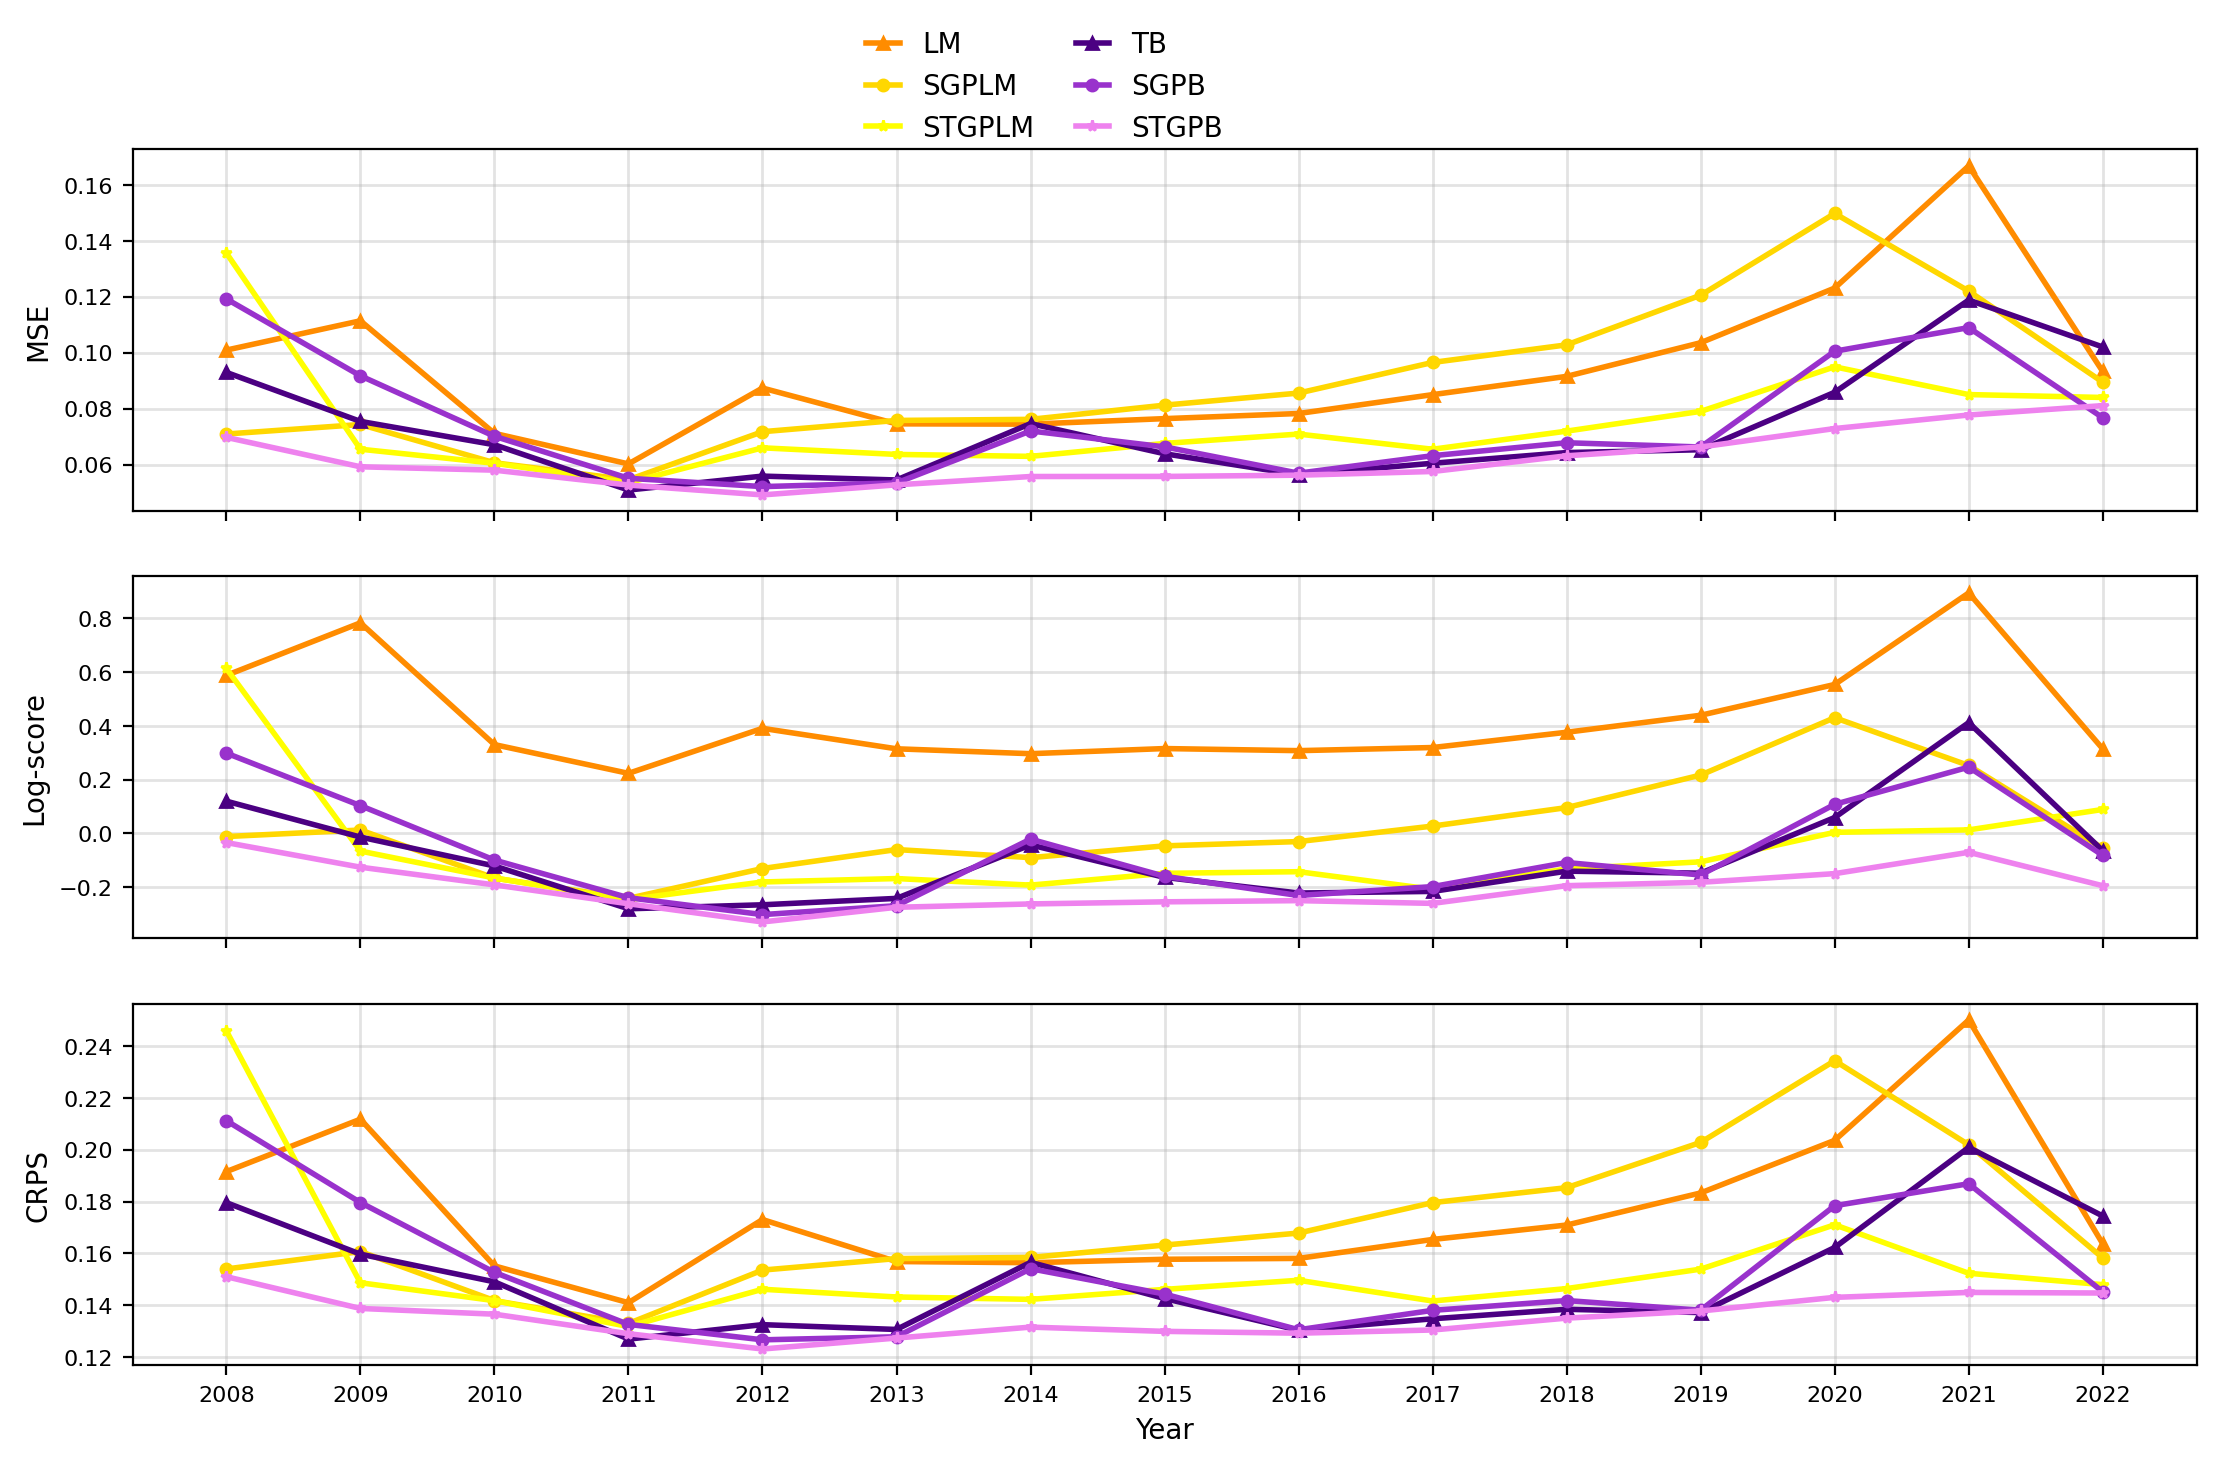

In [18]:
from lgd_eval_utils import plot_os_zoctn_performance

plot_os_zoctn_performance(year_range, ilm_results, itb_results, gplm_results, gpb_results)